In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVR

## 1. Load data and EDA

In [2]:
path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")

files = os.listdir(path)
print(files)

100%|██████████████████████████████████████| 6.22k/6.22k [00:00<00:00, 5.99MB/s]

Extracting files...
['ENB2012_data.csv']


In [3]:
columns = [
    "Relative Compactness",
    "Surface Area",
    "Wall Area",
    "Roof Area",
    "Overall Height",
    "Orientation",
    "Glazing Area",
    "Glazing Area Distribution",
    "Heating Load",
    "Cooling Load"
]

In [4]:
filepath = os.path.join(path, 'ENB2012_data.csv')
data = pd.read_csv(filepath, names=columns)
data = data.drop(index=0).reset_index(drop=True)
data = data.apply(pd.to_numeric)

data.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
print("Shape: ", data.shape)

data.info()

Shape:  (768, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative Compactness       768 non-null    float64
 1   Surface Area               768 non-null    float64
 2   Wall Area                  768 non-null    float64
 3   Roof Area                  768 non-null    float64
 4   Overall Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing Area               768 non-null    float64
 7   Glazing Area Distribution  768 non-null    int64  
 8   Heating Load               768 non-null    float64
 9   Cooling Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [6]:
data.describe()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


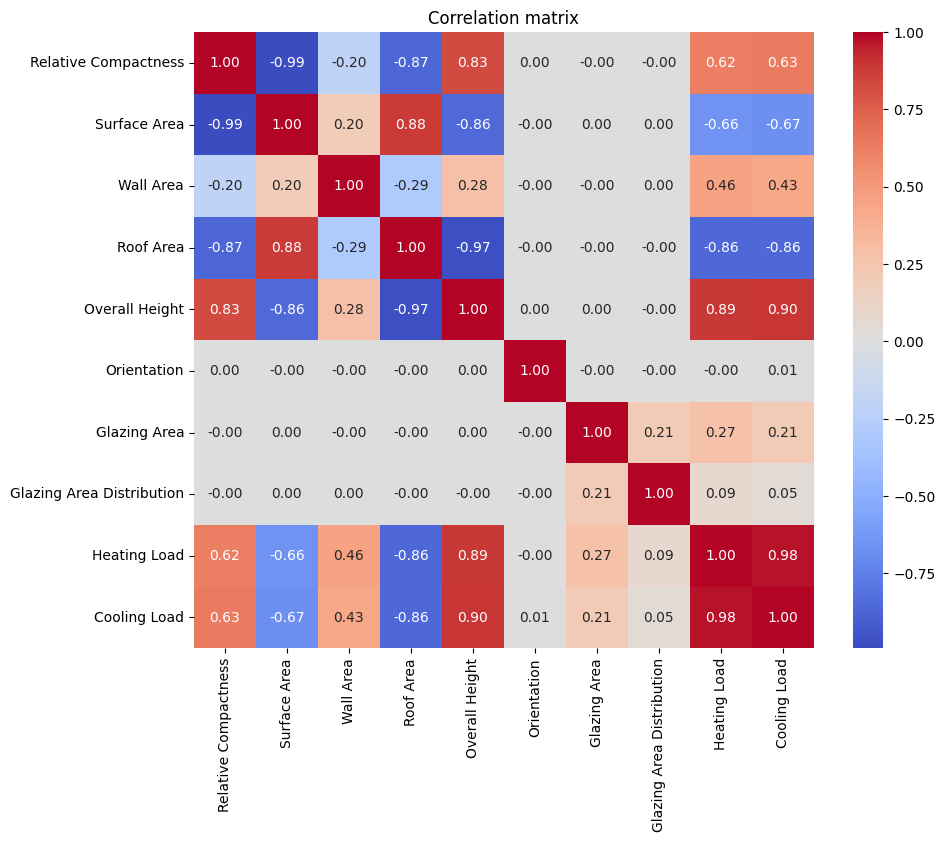

In [7]:
# Correlations

plt.figure(figsize=(10, 8))

sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

## 2: Prepare data for modeling

In [8]:
# I choose "Heating Load" as target variable

X = data.drop(columns=["Heating Load", "Cooling Load"])
y = data["Heating Load"]

In [10]:
# Test train split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Models

* Baseline model: Linear Regression
* SVR

In [14]:
# Linear regression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
print("Linear regression RMSE: ", rmse_lr)

Linear regression RMSE:  3.0254235827736182


In [15]:
# Support vector regression

svr = SVR(kernel="rbf")  # gaussian
svr.fit(X_train_scaled, y_train)

pred_svr = svr.predict(X_test_scaled)

rmse_svr = np.sqrt(mean_squared_error(y_test, pred_svr))
print("SVR RMSE: ", rmse_svr)

SVR RMSE:  2.8230595003737626


SVR with gaussian kernel performs better than linear regression.

## 4. Hyperparameter tuning

In [22]:
# Parameter exploration

param_grid = {
    "C": [0.1, 1, 10, 100],  # penalization parameter
    "epsilon": [0.01, 0.1, 0.5],  # toleramce parameter
    "gamma": ["scale", "auto", 0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVR(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

In [23]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100], 'epsilon': [0.01, 0.1, 0.5],
                         'gamma': ['scale', 'auto', 0.01, 0.1, 1]},
             scoring='neg_root_mean_squared_error')

In [24]:
print("Best parameters: ", grid.best_params_)

Best parameters:  {'C': 100, 'epsilon': 0.1, 'gamma': 'auto'}


In [25]:
# Best model

best_svr = grid.best_estimator_
pred_best = best_svr.predict(X_test_scaled)

rmse_best = np.sqrt(mean_squared_error(y_test, pred_best))
print("Best SVR RMSE: ", rmse_best)

Best SVR RMSE:  0.7347042231799905


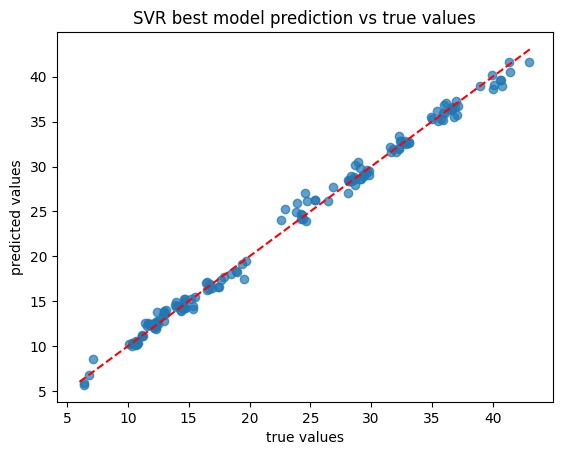

In [26]:
# Visualization

plt.scatter(y_test, pred_best, alpha=0.7)

plt.xlabel("true values")
plt.ylabel("predicted values")
plt.title("SVR best model prediction vs true values")

plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")

plt.show()

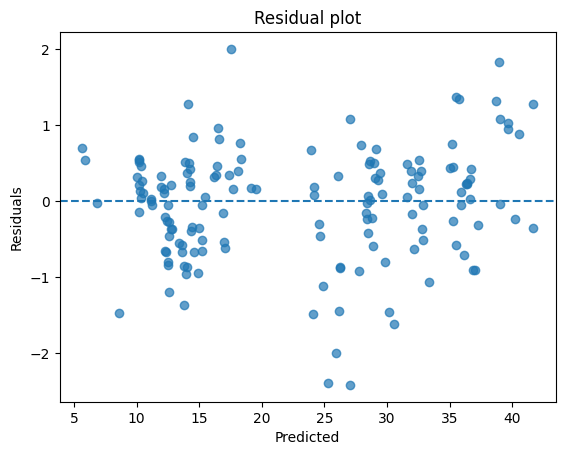

In [27]:
# Residual plot

residuals = y_test - pred_best

plt.scatter(pred_best, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual plot")

plt.show()

## 5. Kernels comparison 

* Linear
* Polunomial
* RBF

In [36]:
# Find the best parameters for each model

param_grid = {
    "kernel": ["linear", "poly", "rbf"],
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "degree": [2, 3]
}

grid = GridSearchCV(
    SVR(),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [37]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'degree': [2, 3],
                         'epsilon': [0.01, 0.1, 0.5],
                         'gamma': ['scale', 'auto', 0.01, 0.1],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='neg_root_mean_squared_error')

In [38]:
results = pd.DataFrame(grid.cv_results_)

In [39]:
# Best model for each kernel

best_per_kernel = results.groupby("param_kernel")["mean_test_score"].max()

print(best_per_kernel)

param_kernel
linear   -2.975469
poly     -2.540924
rbf      -1.158890
Name: mean_test_score, dtype: float64
